In [53]:
import sys
from pathlib import Path

# Add the project root to the Python path
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

In [54]:
import pandas as pd
from src.data_loader import load_data
from src.analysis import normalize_timestamps, plot_news_by_day
from nltk.sentiment import SentimentIntensityAnalyzer
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import nltk

In [55]:
# Load news data
news = pd.read_csv('../../data/news_raw_data.csv')
news_df = pd.DataFrame(news)
news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [56]:
goog_news_df = news_df[news_df['stock'] == 'GOOG']
goog_news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
565380,568379,"Facebook, Snap Analyst Projects Q2 Revenue Ups...",https://www.benzinga.com/analyst-ratings/analy...,Shanthi Rexaline,2020-06-10 15:25:13-04:00,GOOG
565381,568380,How Cannabis Company Cannaphyll Is Marketing O...,https://www.benzinga.com/markets/cannabis/20/0...,Jaycee Tenn,2020-06-10 13:18:50-04:00,GOOG
565382,568381,"Twitter, Square Will Mark Juneteenth As Holida...",https://www.benzinga.com/news/20/06/16218441/t...,Shivdeep Dhaliwal,2020-06-10 00:28:00-04:00,GOOG
565383,568382,Price Over Earnings Overview: Alphabet,https://www.benzinga.com/intraday-update/20/06...,Benzinga Insights,2020-06-09 14:39:26-04:00,GOOG
565384,568383,Google Maps To Offer Relevant Local COVID-19 I...,https://www.benzinga.com/news/20/06/16208274/g...,Shivdeep Dhaliwal,2020-06-09 03:51:41-04:00,GOOG


In [57]:
# Load GOOG stock data
goog_df = load_data(filepath='../../data/finance-data/GOOG.csv')
goog_df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,7.948608,7.960977,7.557264,7.633949,144961322.0
2009-01-05,8.115089,8.194003,7.792268,7.940692,196293007.0
2009-01-06,8.263762,8.430492,8.074027,8.237046,257971329.0
2009-01-07,7.965677,8.185839,7.885034,8.121770,180453860.0
2009-01-08,8.044340,8.044340,7.850152,7.873406,144567852.0


### **Date Alignment**

In [58]:
# Call normalize_timestamps with goog_news_df and stock_df
normalized_news = normalize_timestamps(
    stock_df=goog_df.reset_index().copy(),
    news_df=goog_news_df.copy(),
    sticker='GOOG',
    news_date_col='date',
    stock_date_col='Date'
)
normalized_news.head()


News timestamps after timezone normalization:
565380   2020-06-10 19:25:13
565381   2020-06-10 17:18:50
565382   2020-06-10 04:28:00
565383   2020-06-09 18:39:26
565384   2020-06-09 07:51:41
Name: date, dtype: datetime64[ns]

GOOG Stock timestamps after timezone normalization:
0   2009-01-02
1   2009-01-05
2   2009-01-06
3   2009-01-07
4   2009-01-08
Name: Date, dtype: datetime64[ns]


,Unnamed: 0,headline,url,publisher,date,stock,trading_date
565380,568379,"Facebook, Snap Analyst Projects Q2 Revenue Ups...",https://www.benzinga.com/analyst-ratings/analy...,Shanthi Rexaline,2020-06-10 19:25:13,GOOG,2020-06-10
565381,568380,How Cannabis Company Cannaphyll Is Marketing O...,https://www.benzinga.com/markets/cannabis/20/0...,Jaycee Tenn,2020-06-10 17:18:50,GOOG,2020-06-10
565382,568381,"Twitter, Square Will Mark Juneteenth As Holida...",https://www.benzinga.com/news/20/06/16218441/t...,Shivdeep Dhaliwal,2020-06-10 04:28:00,GOOG,2020-06-10
565383,568382,Price Over Earnings Overview: Alphabet,https://www.benzinga.com/intraday-update/20/06...,Benzinga Insights,2020-06-09 18:39:26,GOOG,2020-06-09
565384,568383,Google Maps To Offer Relevant Local COVID-19 I...,https://www.benzinga.com/news/20/06/16208274/g...,Shivdeep Dhaliwal,2020-06-09 07:51:41,GOOG,2020-06-09


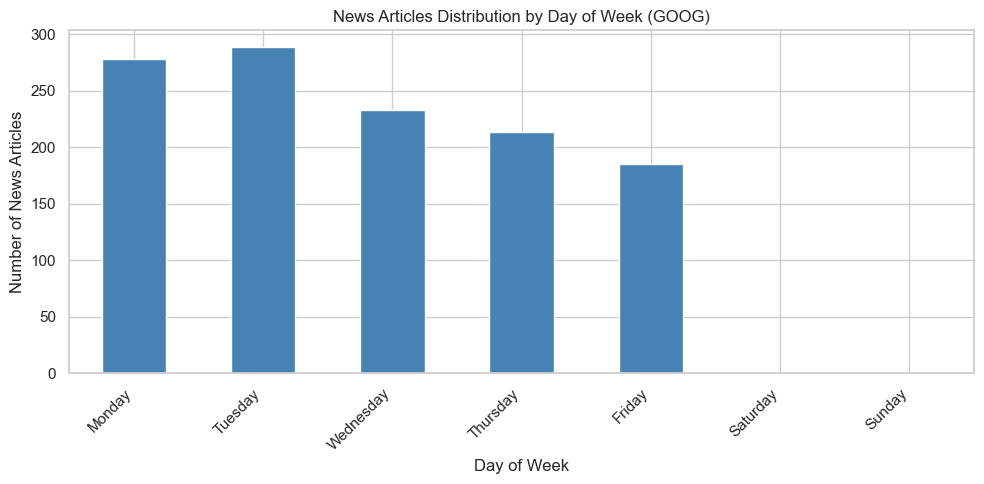

In [59]:
plot_news_by_day(normalized_news, 'GOOG')

### **Sentiment Analysis**

In [60]:
nltk.download('vader_lexicon')

# Initialize the analyzer
sia = SentimentIntensityAnalyzer()

# Apply VADER to get the 'compound' score for each headline
normalized_news['sentiment_score'] = normalized_news['headline'].apply(lambda x: sia.polarity_scores(x)['compound'])


normalized_news[['headline', 'sentiment_score']].head()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\teMelkishi\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,headline,sentiment_score
565380,"Facebook, Snap Analyst Projects Q2 Revenue Ups...",0.0000
565381,How Cannabis Company Cannaphyll Is Marketing O...,0.1779
565382,"Twitter, Square Will Mark Juneteenth As Holida...",0.7096
565383,Price Over Earnings Overview: Alphabet,0.0000
565384,Google Maps To Offer Relevant Local COVID-19 I...,0.0000


In [61]:
# Calculate daily percentage return: (Close_t - Close_t-1) / Close_t-1 * 100
goog_df['daily_return'] = goog_df['Close'].pct_change() * 100

# Ensure the index is in datetime format and keep only the date part
goog_df.index = pd.to_datetime(goog_df.index).date

goog_df[['Close', 'daily_return']].head()

,Close,daily_return
2009-01-02,7.948608,NaN
2009-01-05,8.115089,2.094467
2009-01-06,8.263762,1.832057
2009-01-07,7.965677,-3.607137
2009-01-08,8.044340,0.987523


### **Aggregate and Correlate**

In [62]:
# Average daily sentiment score
daily_sentiment = (
    normalized_news
    .groupby('trading_date', as_index=False)['sentiment_score']
    .mean()
    .rename(columns={'sentiment_score': 'avg_sentiment'})
)

# Merge daily sentiment with daily stock return
goog_df_reset = goog_df.reset_index()
if 'index' in goog_df_reset.columns and 'Date' not in goog_df_reset.columns:
    goog_df_reset = goog_df_reset.rename(columns={'index': 'Date'})

daily_sentiment['trading_date'] = pd.to_datetime(daily_sentiment['trading_date'])
goog_df_reset['Date'] = pd.to_datetime(goog_df_reset['Date'])

merged_data = daily_sentiment.merge(
    goog_df_reset[['Date', 'daily_return']],
    left_on='trading_date',
    right_on='Date',
    how='inner'
)

merged_data.head()

,trading_date,avg_sentiment,Date,daily_return
0,2018-11-13,0.00000,2018-11-13,-0.248399
1,2018-11-14,0.40370,2018-11-14,0.734507
2,2018-11-15,0.21800,2018-11-15,2.016938
3,2018-11-16,-0.10175,2018-11-16,-0.302427
4,2018-11-19,0.06100,2018-11-19,-3.908660


In [63]:
# Calculate the Pearson correlation coefficient between average daily sentiment scores and daily stock returns
correlation = merged_data['avg_sentiment'].corr(merged_data['daily_return'])
print(f"Pearson Correlation Coefficient: {correlation:.4f}")

Pearson Correlation Coefficient: 0.1693


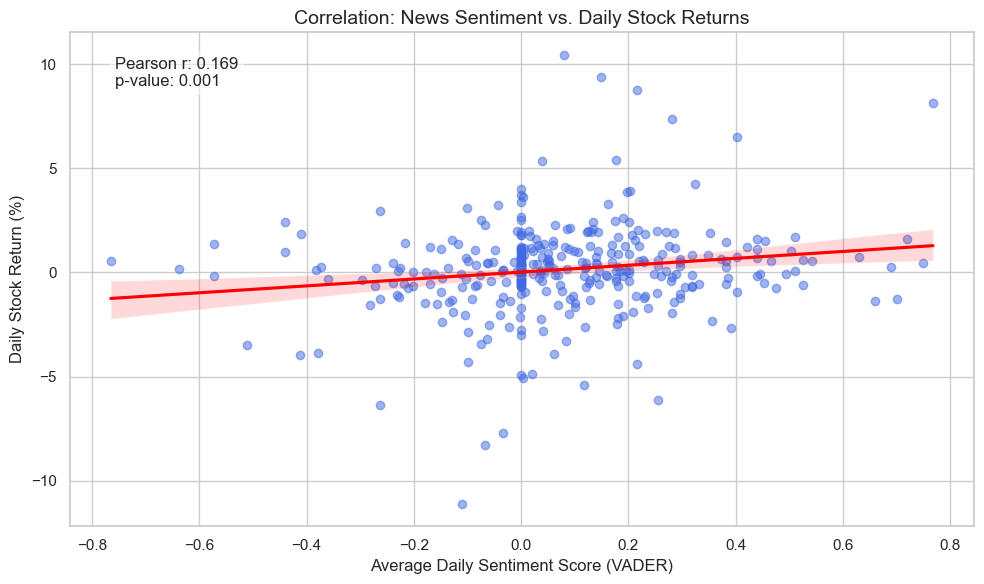

In [64]:


# Use the merged dataset created earlier
plot_data = merged_data.dropna(subset=['avg_sentiment', 'daily_return'])

# Pearson correlation + p-value
corr_val, p_val = pearsonr(plot_data['avg_sentiment'], plot_data['daily_return'])

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.regplot(
    x='avg_sentiment',
    y='daily_return',
    data=plot_data,
    scatter_kws={'alpha': 0.5, 'color': 'royalblue'},
    line_kws={'color': 'red', 'label': 'Regression Line'}
)

plt.text(
    0.05, 0.95,
    f'Pearson r: {corr_val:.3f}\np-value: {p_val:.3f}',
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5)
)

plt.title('Correlation: News Sentiment vs. Daily Stock Returns', fontsize=14)
plt.xlabel('Average Daily Sentiment Score (VADER)', fontsize=12)
plt.ylabel('Daily Stock Return (%)', fontsize=12)
plt.tight_layout()
plt.show()


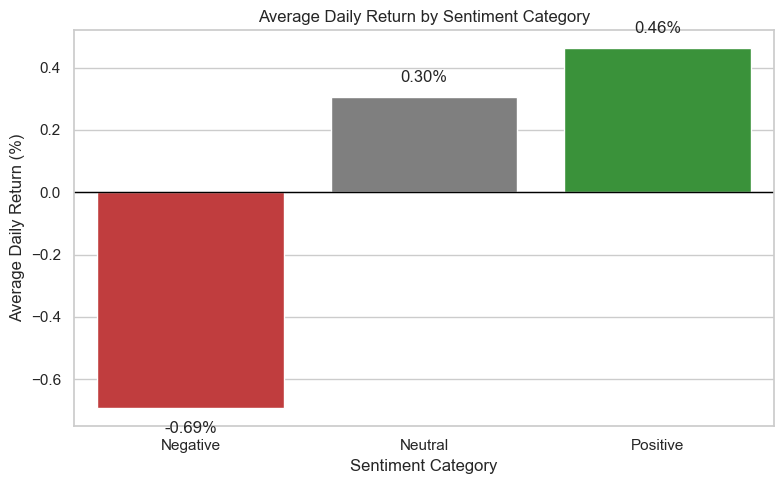

In [65]:
# Classify each day by average sentiment score
classified_data = merged_data.copy()
classified_data['sentiment_category'] = pd.cut(
    classified_data['avg_sentiment'],
    bins=[-float('inf'), -1e-6, 1e-6, float('inf')],
    labels=['Negative', 'Neutral', 'Positive']
)

# Compute average daily return per sentiment category
avg_return_by_sentiment = (
    classified_data
    .groupby('sentiment_category', observed=False)['daily_return']
    .mean()
    .reindex(['Negative', 'Neutral', 'Positive'])
)

# Plot as bar chart
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=avg_return_by_sentiment.index,
    y=avg_return_by_sentiment.values,
    palette=['#d62728', '#7f7f7f', '#2ca02c']
)

ax.axhline(0, color='black', linewidth=1)
ax.set_title('Average Daily Return by Sentiment Category')
ax.set_xlabel('Sentiment Category')
ax.set_ylabel('Average Daily Return (%)')

for i, v in enumerate(avg_return_by_sentiment.values):
    ax.text(i, v + (0.05 if v >= 0 else -0.08), f'{v:.2f}%', ha='center')

plt.tight_layout()
plt.show()